# 01 — Data Exploration
**Traffic Sign Recognition · GTSRB Dataset**

Goals:
- Load and inspect `Train.csv` and `Meta.csv`
- Understand column meanings and data types
- Visualise the class distribution
- Display sample raw images from each class

---

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src/ importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from src.config import DATA_DIR, NUM_CLASSES, CLASS_NAMES
from src.data_loader import load_csv

print("Data directory:", DATA_DIR)

Data directory: c:\Users\Mega-PC\Desktop\stage Elevvo\Task_8_Traffic_Sign_Recognition\data


## 1. Load CSVs

In [3]:
train_df, meta_df = load_csv(DATA_DIR)
display(train_df.head())

Train CSV  :  39209 rows  |  columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Meta  CSV  :     43 rows  |  columns: ['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId']


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [4]:
print("\nColumn dtypes:")
print(train_df.dtypes)
print("\nMissing values:")
print(train_df.isnull().sum())


Column dtypes:
Width      int64
Height     int64
Roi.X1     int64
Roi.Y1     int64
Roi.X2     int64
Roi.Y2     int64
ClassId    int64
Path         str
dtype: object

Missing values:
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64


In [5]:
print("Metadata:")
display(meta_df.head(10))

Metadata:


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22
5,Meta/12.png,12,2,2,2.3
6,Meta/13.png,13,4,0,2.1
7,Meta/14.png,14,3,0,2.2
8,Meta/15.png,15,1,0,3.1
9,Meta/16.png,16,1,0,3.3


## 2. Class Distribution

In [6]:
class_counts = train_df['ClassId'].value_counts().sort_index()
print(f"Total images : {len(train_df):,}")
print(f"Unique classes: {train_df['ClassId'].nunique()}")
print(f"Min per class : {class_counts.min()}")
print(f"Max per class : {class_counts.max()}")

Total images : 39,209
Unique classes: 43
Min per class : 210
Max per class : 2250


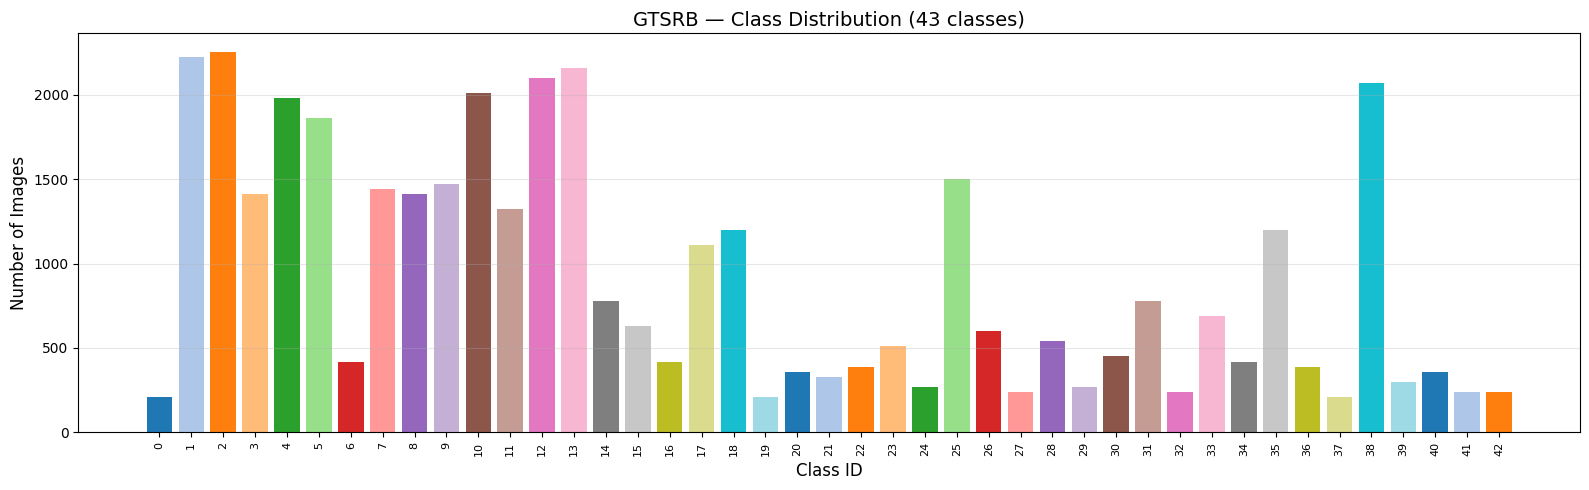

In [7]:
plt.figure(figsize=(16, 5))
colors = plt.cm.tab20.colors
bars = plt.bar(class_counts.index, class_counts.values,
               color=[colors[i % 20] for i in range(NUM_CLASSES)])
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('GTSRB — Class Distribution (43 classes)', fontsize=14)
plt.xticks(range(0, 43), rotation=90, fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Sample Images — Raw (before preprocessing)

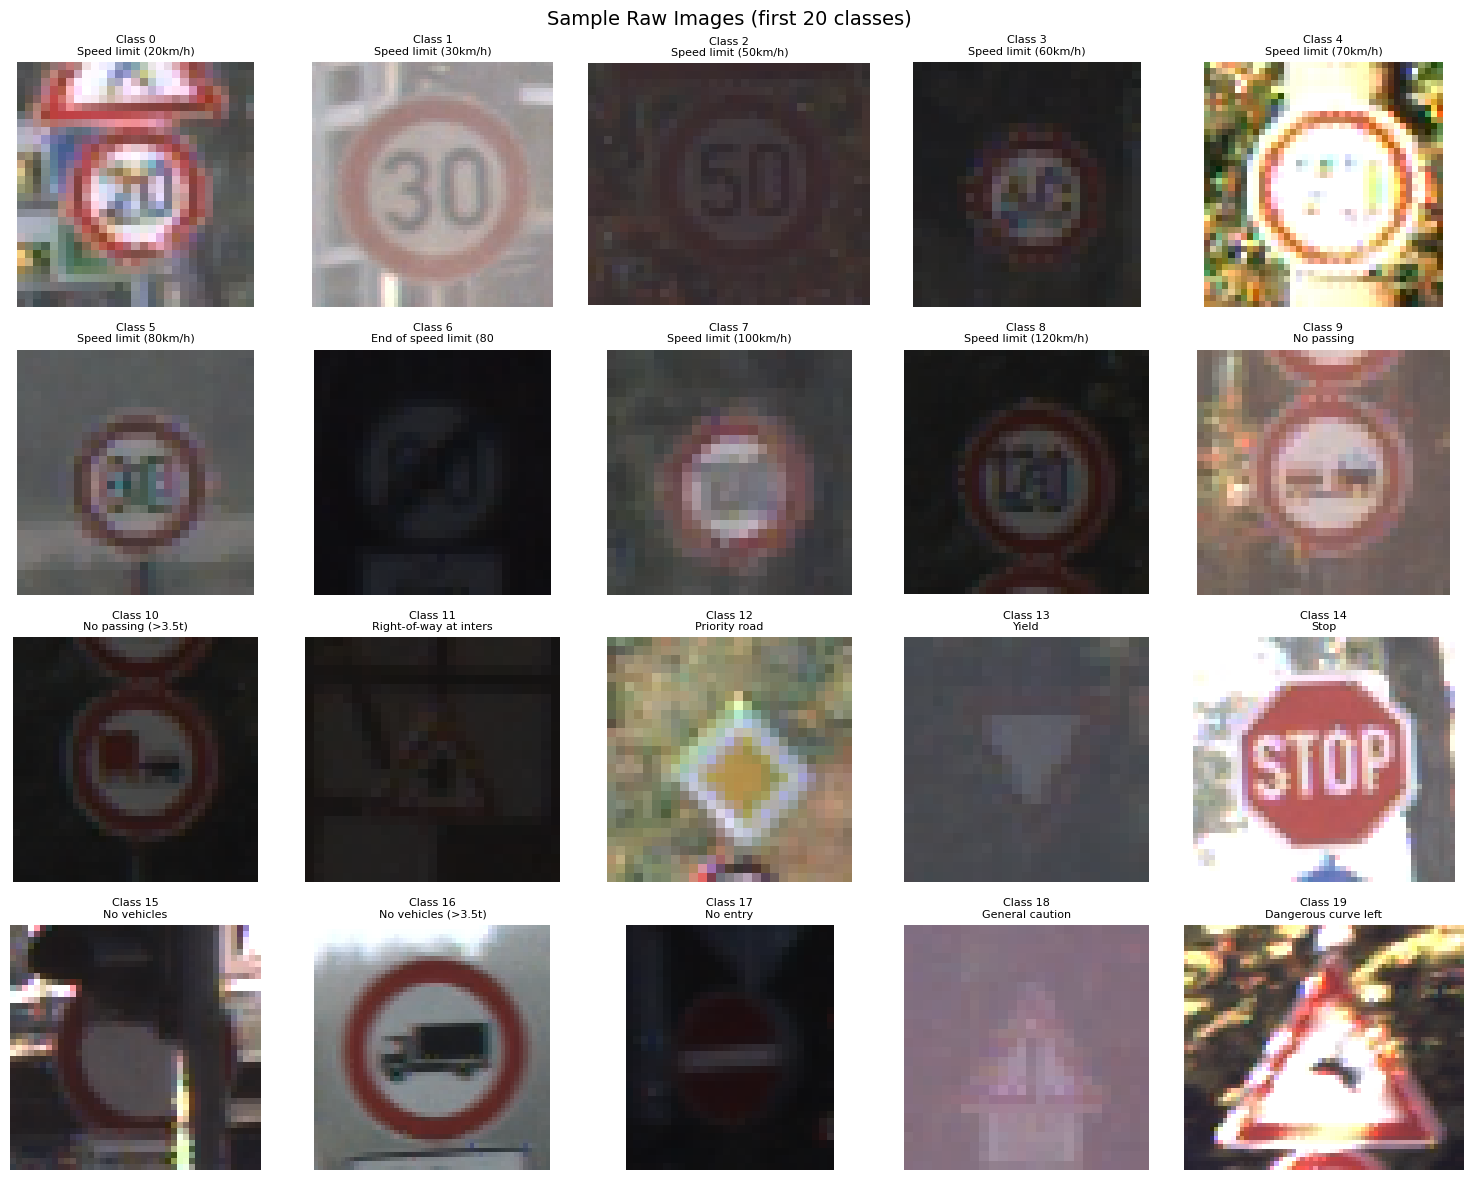

In [8]:
# Show one raw image per class (first 20 classes)
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

for class_id in range(20):
    row = train_df[train_df['ClassId'] == class_id].iloc[0]
    img_path = os.path.join(DATA_DIR, row['Path'])
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[class_id].imshow(img)
    axes[class_id].set_title(f'Class {class_id}\n{CLASS_NAMES[class_id][:22]}',
                             fontsize=8)
    axes[class_id].axis('off')

plt.suptitle('Sample Raw Images (first 20 classes)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Image Dimension Statistics

In [9]:
print("Image width  stats:")
print(train_df['Width'].describe())
print("\nImage height stats:")
print(train_df['Height'].describe())

Image width  stats:
count    39209.000000
mean        50.835880
std         24.306933
min         25.000000
25%         35.000000
50%         43.000000
75%         58.000000
max        243.000000
Name: Width, dtype: float64

Image height stats:
count    39209.000000
mean        50.328930
std         23.115423
min         25.000000
25%         35.000000
50%         43.000000
75%         58.000000
max        225.000000
Name: Height, dtype: float64


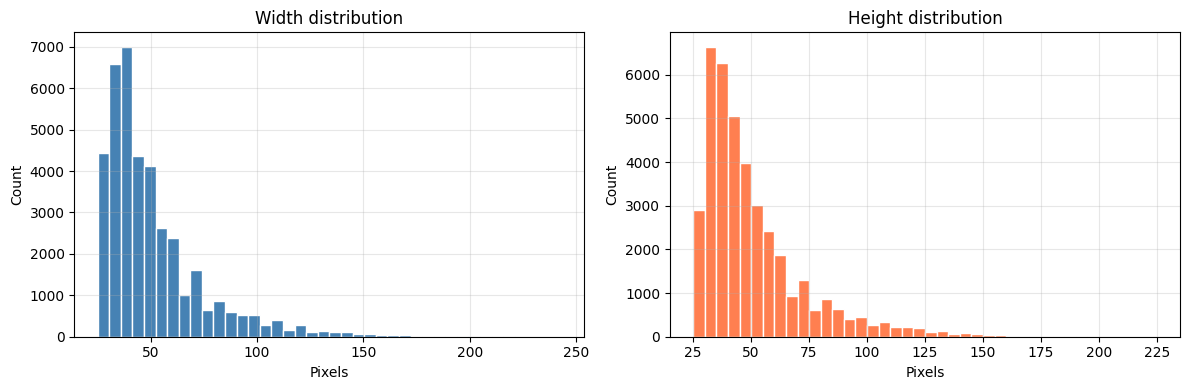

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['Width'],  bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Width distribution')
axes[1].hist(train_df['Height'], bins=40, color='coral',     edgecolor='white')
axes[1].set_title('Height distribution')
for ax in axes:
    ax.set_xlabel('Pixels')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()